In [1]:
import numpy as np, pandas as pd, librosa, librosa.display
import matplotlib.pyplot as plt, seaborn as sns
import os, glob, warnings; warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import joblib, tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, LSTM, Dropout, Conv1D, MaxPooling1D,
    Bidirectional, BatchNormalization, Input,
    MultiHeadAttention, GlobalAveragePooling1D, LayerNormalization
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

In [2]:
# ── Configuration ──────────────────────────────────────────────────────────────
CREMA_PATH   = r'..\data\Crema'
RAVDESS_PATH = r'..\data\Ravdess\audio_speech_actors_01-24'
TESS_PATH    = r'..\data\Tess'
os.makedirs('../models', exist_ok=True)
MODEL_SAVE_PATH  = '../models/distress_detection_model_v2.keras'
SCALER_SAVE_PATH = '../models/feature_scaler_v2.joblib'

DISTRESS_EMOTIONS     = ['angry', 'fear', 'sad']
NON_DISTRESS_EMOTIONS = ['happy', 'neutral']
SAMPLE_RATE = 22050
BATCH_SIZE  = 32
MAX_EPOCHS  = 150

## 1. Enhanced Feature Extraction (275-dim)
Adds **delta-MFCC**, **delta²-MFCC**, **ZCR**, and **RMS Energy** on top of the original 193-dim vector.

In [3]:
def _feat_from_array(X, sr):
    result, stft = [], np.abs(librosa.stft(X))
    mfccs = librosa.feature.mfcc(y=X, sr=sr, n_mfcc=40)
    result += [np.mean(mfccs.T, axis=0),
               np.mean(librosa.feature.delta(mfccs).T, axis=0),
               np.mean(librosa.feature.delta(mfccs, order=2).T, axis=0)]
    result.append(np.mean(librosa.feature.chroma_stft(S=stft, sr=sr, n_chroma=12).T, axis=0))
    result.append(np.mean(librosa.feature.melspectrogram(y=X, sr=sr, n_mels=128, fmax=8000).T, axis=0))
    result.append(np.mean(librosa.feature.spectral_contrast(S=stft, sr=sr, n_bands=6).T, axis=0))
    result.append(np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(X), sr=sr).T, axis=0))
    result.append(np.array([np.mean(librosa.feature.zero_crossing_rate(X))]))
    result.append(np.array([np.mean(librosa.feature.rms(y=X))]))
    return np.hstack(result)

def extract_features(file_path):
    try:
        X, sr = librosa.load(file_path, sr=SAMPLE_RATE, res_type='soxr_hq')
        return _feat_from_array(X, sr)
    except Exception as e:
        print(f"Error {file_path}: {e}"); return None

## 2. Data Augmentation (4× per sample)
Each audio file generates 5 feature vectors: original + noise injection + pitch shift +2 semitones + time stretch 0.9× + time stretch 1.1×.

In [4]:
def augment_and_extract(file_path):
    try:
        X, sr = librosa.load(file_path, sr=SAMPLE_RATE, res_type='soxr_hq')
    except: return []
    variants = [X]
    for fn in [
        lambda x: x + np.random.normal(0, 0.005, x.shape),
        lambda x: librosa.effects.pitch_shift(x, sr=sr, n_steps=2),
        lambda x: librosa.effects.time_stretch(x, rate=0.9),
        lambda x: librosa.effects.time_stretch(x, rate=1.1),
    ]:
        try: variants.append(fn(X))
        except: pass
    return [f for v in variants if (f := _safe_feat(v, sr)) is not None]

def _safe_feat(v, sr):
    try: return _feat_from_array(v, sr)
    except: return None

## 3. Dataset Loaders

In [25]:
def _load_dataset(files_iter, augment=True):
    features, emotions, distress_labels = [], [], []
    for fp, emo in files_iter:
        if emo == 'disgust': continue
        dist  = 1 if emo in DISTRESS_EMOTIONS else 0
        feats = augment_and_extract(fp) if augment else (
            [f] if (f := extract_features(fp)) is not None else []
        )
        for feat in feats:
            features.append(feat); emotions.append(emo); distress_labels.append(dist)
    return np.array(features), np.array(emotions), np.array(distress_labels)

def crema_iter(path):
    emap = {'ANG':'angry','FEA':'fear','HAP':'happy','NEU':'neutral','SAD':'sad','DIS':'disgust'}
    for fp in glob.glob(os.path.join(path, '*.wav')):
        code = os.path.basename(fp).split('_')[2]
        if code in emap: yield fp, emap[code]

def ravdess_iter(path):
    emap = {'01':'neutral','02':'neutral','03':'happy','04':'sad',
            '05':'angry','06':'fear','07':'disgust','08':'happy'}
    for folder in glob.glob(os.path.join(path, 'Actor_*')):
        for fp in glob.glob(os.path.join(folder, '*.wav')):
            code = os.path.basename(fp).split('-')[2]
            if code in emap: yield fp, emap[code]

def tess_iter(path):
    for folder in glob.glob(os.path.join(path, '*')):
        if not os.path.isdir(folder): continue
        name = os.path.basename(folder).lower()
        if   'angry'    in name: emo = 'angry'
        elif 'fear'     in name: emo = 'fear'
        elif 'happy'    in name: emo = 'happy'
        elif 'neutral'  in name: emo = 'neutral'
        elif 'sad'      in name: emo = 'sad'
        elif 'surprise' in name: emo = 'happy'
        elif 'disgust'  in name: continue
        else:                     continue
        for fp in glob.glob(os.path.join(folder, '*.wav')): yield fp, emo

In [27]:
# Load each dataset — set augment=False to skip augmentation (faster, lower accuracy)
AUGMENT = True

crema_feat, crema_emo, crema_dist = (
    _load_dataset(crema_iter(CREMA_PATH), AUGMENT)
    if os.path.exists(CREMA_PATH)
    else (np.array([]), np.array([]), np.array([]))
)
print(f"CREMA-D : {len(crema_feat)} samples")

ravdess_feat, ravdess_emo, ravdess_dist = (
    _load_dataset(ravdess_iter(RAVDESS_PATH), AUGMENT)
    if os.path.exists(RAVDESS_PATH)
    else (np.array([]), np.array([]), np.array([]))
)
print(f"RAVDESS : {len(ravdess_feat)} samples")

tess_feat, tess_emo, tess_dist = (
    _load_dataset(tess_iter(TESS_PATH), AUGMENT)
    if os.path.exists(TESS_PATH)
    else (np.array([]), np.array([]), np.array([]))
)
print(f"TESS    : {len(tess_feat)} samples")

CREMA-D : 30855 samples
RAVDESS : 6240 samples
TESS    : 12000 samples


## 4. Combine & Explore

Total: 49095 samples, dim=275

Emotion distribution:
happy      12275
angry       9315
fear        9315
sad         9315
neutral     8875
Name: count, dtype: int64

Distress: 27945  Non-Distress: 21150


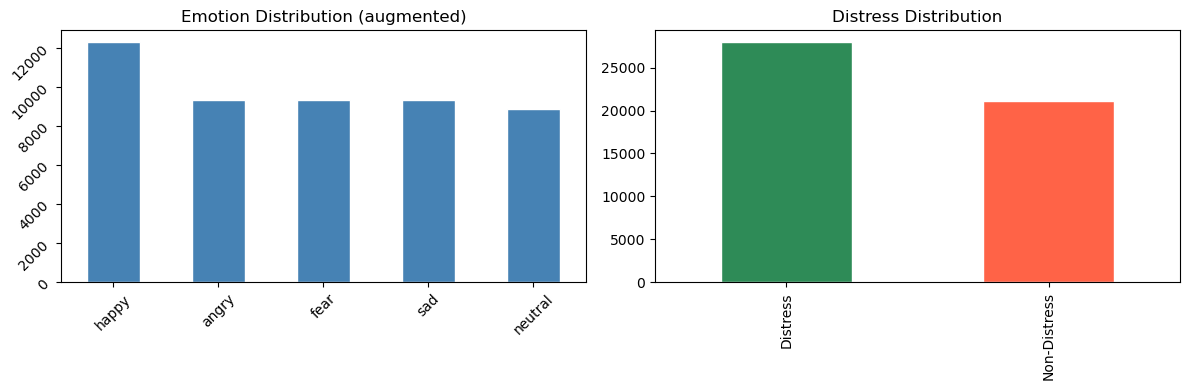

In [28]:
parts = [(crema_feat, crema_emo, crema_dist),
         (ravdess_feat, ravdess_emo, ravdess_dist),
         (tess_feat, tess_emo, tess_dist)]
X          = np.concatenate([p[0] for p in parts if len(p[0]) > 0])
y_emotions = np.concatenate([p[1] for p in parts if len(p[1]) > 0])
y_distress = np.concatenate([p[2] for p in parts if len(p[2]) > 0])
print(f"Total: {len(X)} samples, dim={X.shape[1]}")
print("\nEmotion distribution:")
print(pd.Series(y_emotions).value_counts())
print(f"\nDistress: {int(np.sum(y_distress))}  Non-Distress: {int(len(y_distress)-np.sum(y_distress))}")

fig, ax = plt.subplots(1, 2, figsize=(12,4))
pd.Series(y_emotions).value_counts().plot(kind='bar', ax=ax[0], color='steelblue', edgecolor='white')
ax[0].set_title('Emotion Distribution (augmented)'); ax[0].tick_params(rotation=45)
pd.Series(y_distress).value_counts().rename({0:'Non-Distress',1:'Distress'}).plot(
    kind='bar', ax=ax[1], color=['seagreen','tomato'], edgecolor='white')
ax[1].set_title('Distress Distribution')
plt.tight_layout(); plt.savefig('../img/data_distribution_v2.png', dpi=120); plt.show()

## 5. Preprocessing & Splits

In [29]:
le         = LabelEncoder()
y_emo_enc  = le.fit_transform(y_emotions)
y_emo_cat  = to_categorical(y_emo_enc)
n_classes  = y_emo_cat.shape[1]
joblib.dump(le, '../models/label_encoder_v2.joblib')
print("Emotion classes:", list(le.classes_))

X_train, X_tmp, yd_tr, yd_tmp, ye_tr, ye_tmp = train_test_split(
    X, y_distress, y_emo_cat, test_size=0.30, random_state=42, stratify=y_distress)
X_val, X_test, yd_val, yd_te, ye_val, ye_te = train_test_split(
    X_tmp, yd_tmp, ye_tmp, test_size=0.667, random_state=42, stratify=yd_tmp)
print(f"Train {len(X_train)} | Val {len(X_val)} | Test {len(X_test)}")

sc = StandardScaler()
Xtr = sc.fit_transform(X_train).reshape(-1, X_train.shape[1], 1)
Xvl = sc.transform(X_val).reshape(-1, X_val.shape[1], 1)
Xte = sc.transform(X_test).reshape(-1, X_test.shape[1], 1)
joblib.dump(sc, SCALER_SAVE_PATH)
print(f"Input shape: {Xtr.shape}")

Emotion classes: [np.str_('angry'), np.str_('fear'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]
Train 34366 | Val 4904 | Test 9825
Input shape: (34366, 275, 1)


## 6. Class Weights

In [30]:
cw     = compute_class_weight('balanced', classes=np.unique(yd_tr), y=yd_tr)
cw_d   = dict(enumerate(cw))
sw_tr  = np.array([cw_d[int(d)] for d in yd_tr])
print("Distress class weights:", cw_d)

Distress class weights: {0: np.float64(1.1606214116852416), 1: np.float64(0.8784315730279638)}


## 7. Model Architecture — CNN + BiLSTM + Multi-Head Attention
```
Input (275, 1)
  → Conv1D(128) → BN → Pool → Drop(0.25)
  → Conv1D(256) → BN → Pool → Drop(0.25)
  → Conv1D(256) → BN → Pool → Drop(0.25)
  → Conv1D(128) → BN → Pool → Drop(0.25)
  → BiLSTM(128, return_seq=True) → Drop(0.3)
  → MultiHeadAttention(4 heads, key_dim=32) + Residual + LayerNorm
  → GlobalAveragePooling → Drop(0.3)
  → Dense(256→128) → Drop(0.3)
  ├── [Distress head] Dense(64) → sigmoid
  └── [Emotion head]  Dense(64) → softmax
```

In [31]:
def build_model(input_shape, n_emo):
    inp = Input(shape=input_shape)

    x = Conv1D(128, 5, activation='relu', padding='same')(inp)
    x = BatchNormalization()(x); x = MaxPooling1D(2)(x); x = Dropout(0.25)(x)

    x = Conv1D(256, 5, activation='relu', padding='same')(x)
    x = BatchNormalization()(x); x = MaxPooling1D(2)(x); x = Dropout(0.25)(x)

    x = Conv1D(256, 3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x); x = MaxPooling1D(2)(x); x = Dropout(0.25)(x)

    x = Conv1D(128, 3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x); x = MaxPooling1D(2)(x); x = Dropout(0.25)(x)

    x = Bidirectional(LSTM(128, return_sequences=True))(x); x = Dropout(0.3)(x)

    attn = MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.1)(x, x)
    x    = LayerNormalization()(x + attn)
    x    = GlobalAveragePooling1D()(x); x = Dropout(0.3)(x)

    s = Dense(256, activation='relu')(x); s = Dropout(0.3)(s)
    s = Dense(128, activation='relu')(s); s = Dropout(0.3)(s)

    d = Dense(64, activation='relu')(s); d = Dropout(0.2)(d)
    dist_out = Dense(1, activation='sigmoid', name='distress_output')(d)

    e = Dense(64, activation='relu')(s); e = Dropout(0.2)(e)
    emo_out = Dense(n_emo, activation='softmax', name='emotion_output')(e)

    return Model(inputs=inp, outputs=[dist_out, emo_out])

model = build_model((Xtr.shape[1], 1), n_classes)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 275, 1)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 275, 128)          │             768 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 275, 128)          │             512 │ conv1d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d (MaxPooling1D)  │ (None, 137, 128)          │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 137, 128)          │               0 │ max_pooling1d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 137, 256)          │         164,096 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 137, 256)          │           1,024 │ conv1d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_1               │ (None, 68, 256)           │               0 │ batch_normalization_1[0][… │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 68, 256)           │               0 │ max_pooling1d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_2 (Conv1D)             │ (None, 68, 256)           │         196,864 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 68, 256)           │           1,024 │ conv1d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_2               │ (None, 34, 256)           │               0 │ batch_normalization_2[0][… │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 34, 256)           │               0 │ max_pooling1d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_3 (Conv1D)             │ (None, 34, 128)           │          98,432 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 34, 128)           │             51

 Total params: 974,214 (3.72 MB)

 Trainable params: 972,678 (3.71 MB)

 Non-trainable params: 1,536 (6.00 KB)

## 8. Compile & Train

In [1]:
# #: Compile & Train 
# import tensorflow as tf


# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=0.001),
#     loss={
#         'distress_output': 'binary_crossentropy',
#         'emotion_output':  'categorical_crossentropy'
#     },
#     loss_weights={
#         'distress_output': 1.5,
#         'emotion_output':  0.5
#     },
#     metrics={
#         'distress_output': ['accuracy', tf.keras.metrics.AUC(name='auc')],
#         'emotion_output':  ['accuracy']
#     }
# )
# callbacks = [
#     ModelCheckpoint(
#         MODEL_SAVE_PATH,
#         monitor='val_distress_output_accuracy',
#         mode='max', save_best_only=True, verbose=1
#     ),
#     EarlyStopping(
#         monitor='val_distress_output_accuracy',
#         mode='max', patience=20,
#         restore_best_weights=True, verbose=1
#     ),
#     ReduceLROnPlateau(
#         monitor='val_loss',
#         factor=0.5, patience=7,
#         min_lr=1e-7, verbose=1
#     )
# ]


# AUTOTUNE = tf.data.AUTOTUNE

# train_ds = tf.data.Dataset.from_tensor_slices((
#     Xtr,
#     {'distress_output': yd_tr, 'emotion_output': ye_tr},
#     {'distress_output': sw_tr, 'emotion_output': sw_tr}   # weights as 3rd element
# )).shuffle(buffer_size=len(Xtr)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# val_ds = tf.data.Dataset.from_tensor_slices((
#     Xvl,
#     {'distress_output': yd_val, 'emotion_output': ye_val}
# )).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# # ── Train ─────
# history = model.fit(
#     train_ds,                       
#     validation_data=val_ds,
#     epochs=MAX_EPOCHS,
#     callbacks=callbacks,
#     verbose=1
# )


In [37]:
import tensorflow as tf
import numpy as np

# ── Compile (no loss/metrics dicts — handled manually below) ─────────────────
optimizer = keras.optimizers.Adam(learning_rate=0.001)
bce = tf.keras.losses.BinaryCrossentropy()
cce = tf.keras.losses.CategoricalCrossentropy()
train_acc_d = tf.keras.metrics.BinaryAccuracy(name='distress_acc')
train_acc_e = tf.keras.metrics.CategoricalAccuracy(name='emotion_acc')
val_acc_d   = tf.keras.metrics.BinaryAccuracy(name='val_distress_acc')
val_acc_e   = tf.keras.metrics.CategoricalAccuracy(name='val_emotion_acc')
best_val_acc = 0.0

# ── Build tf.data pipelines ───────────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE
train_ds = tf.data.Dataset.from_tensor_slices(
    (Xtr, yd_tr, ye_tr, sw_tr)
).shuffle(len(Xtr)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (Xvl, yd_val, ye_val)
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# ── Training step ─────────────────────────────────────────────────────────────
@tf.function
def train_step(x, y_d, y_e, sw):
    with tf.GradientTape() as tape:
        y_pred_d, y_pred_e = model(x, training=True)
        loss_d = bce(y_d, y_pred_d, sample_weight=sw)
        loss_e = cce(y_e, y_pred_e, sample_weight=sw)
        total_loss = 1.5 * loss_d + 0.5 * loss_e   # your loss_weights
    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    train_acc_d.update_state(y_d, y_pred_d)
    train_acc_e.update_state(y_e, y_pred_e)
    return total_loss

@tf.function
def val_step(x, y_d, y_e):
    y_pred_d, y_pred_e = model(x, training=False)
    val_acc_d.update_state(y_d, y_pred_d)
    val_acc_e.update_state(y_e, y_pred_e)

# ── Training loop ─────────────────────────────────────────────────────────────
history = {'loss': [], 'distress_acc': [], 'emotion_acc': [],
           'val_distress_acc': [], 'val_emotion_acc': []}
patience_counter = 0
PATIENCE = 20
current_lr = 0.001

for epoch in range(1, MAX_EPOCHS + 1):
    # Train
    epoch_loss = []
    train_acc_d.reset_state(); train_acc_e.reset_state()
    for x_b, yd_b, ye_b, sw_b in train_ds:
        loss = train_step(x_b, yd_b, ye_b, sw_b)
        epoch_loss.append(float(loss))

    # Validate
    val_acc_d.reset_state(); val_acc_e.reset_state()
    for x_b, yd_b, ye_b in val_ds:
        val_step(x_b, yd_b, ye_b)

    # Record
    avg_loss   = np.mean(epoch_loss)
    d_acc      = float(train_acc_d.result())
    e_acc      = float(train_acc_e.result())
    vd_acc     = float(val_acc_d.result())
    ve_acc     = float(val_acc_e.result())
    history['loss'].append(avg_loss)
    history['distress_acc'].append(d_acc)
    history['emotion_acc'].append(e_acc)
    history['val_distress_acc'].append(vd_acc)
    history['val_emotion_acc'].append(ve_acc)

    print(f"Epoch {epoch:03d} — loss: {avg_loss:.4f}  "
          f"d_acc: {d_acc:.4f}  e_acc: {e_acc:.4f}  "
          f"val_d_acc: {vd_acc:.4f}  val_e_acc: {ve_acc:.4f}  lr: {current_lr:.2e}")

    # ModelCheckpoint
    if vd_acc > best_val_acc:
        best_val_acc = vd_acc
        model.save(MODEL_SAVE_PATH)
        print(f"  ✅ Saved best model (val_distress_acc={vd_acc:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1

    # EarlyStopping
    if patience_counter >= PATIENCE:
        print(f"  ⏹ Early stopping at epoch {epoch}")
        break

    # ReduceLROnPlateau (every 7 epochs without improvement)
    if patience_counter > 0 and patience_counter % 7 == 0:
        current_lr = max(current_lr * 0.5, 1e-7)
        optimizer.learning_rate.assign(current_lr)
        print(f"  📉 LR reduced to {current_lr:.2e}")

print(f"\nTraining done. Best val_distress_acc: {best_val_acc:.4f}")


Epoch 001 — loss: 1.5410  d_acc: 0.6522  e_acc: 0.4270  val_d_acc: 0.7492  val_e_acc: 0.5453  lr: 1.00e-03
  ✅ Saved best model (val_distress_acc=0.7492)
Epoch 002 — loss: 1.2615  d_acc: 0.7387  e_acc: 0.5381  val_d_acc: 0.7637  val_e_acc: 0.5522  lr: 1.00e-03
  ✅ Saved best model (val_distress_acc=0.7637)
Epoch 003 — loss: 1.1874  d_acc: 0.7569  e_acc: 0.5788  val_d_acc: 0.7261  val_e_acc: 0.4973  lr: 1.00e-03
Epoch 004 — loss: 1.1443  d_acc: 0.7683  e_acc: 0.5996  val_d_acc: 0.7828  val_e_acc: 0.6007  lr: 1.00e-03
  ✅ Saved best model (val_distress_acc=0.7828)
Epoch 005 — loss: 1.1251  d_acc: 0.7706  e_acc: 0.6099  val_d_acc: 0.7824  val_e_acc: 0.5983  lr: 1.00e-03
Epoch 006 — loss: 1.0931  d_acc: 0.7791  e_acc: 0.6194  val_d_acc: 0.7932  val_e_acc: 0.6378  lr: 1.00e-03
  ✅ Saved best model (val_distress_acc=0.7932)
Epoch 007 — loss: 1.0769  d_acc: 0.7827  e_acc: 0.6291  val_d_acc: 0.7959  val_e_acc: 0.6415  lr: 1.00e-03
  ✅ Saved best model (val_distress_acc=0.7959)
Epoch 008 — loss

## 9. Evaluate on Test Set

In [38]:
best = keras.models.load_model(MODEL_SAVE_PATH)
res  = best.evaluate(Xte, {'distress_output':yd_te,'emotion_output':ye_te}, verbose=0)
for n, v in zip(best.metrics_names, res): print(f"  {n}: {v:.4f}")

preds     = best.predict(Xte, verbose=0)
dp        = (preds[0].ravel() > 0.5).astype(int)
ep        = np.argmax(preds[1], axis=1)
et        = np.argmax(ye_te, axis=1)
da, ea    = accuracy_score(yd_te, dp), accuracy_score(et, ep)

print(f"\n{'='*46}")
print(f"  Distress Detection Accuracy : {da*100:.2f}%")
print(f"  Emotion Classification Acc  : {ea*100:.2f}%")
print(f"{'='*46}")

  loss: 0.8174
  compile_metrics: 0.3202
  distress_output_loss: 0.6721
  emotion_output_loss: 0.8960

  Distress Detection Accuracy : 89.60%
  Emotion Classification Acc  : 76.75%


## 10. Reports & Plots

## 11. Inference Helper

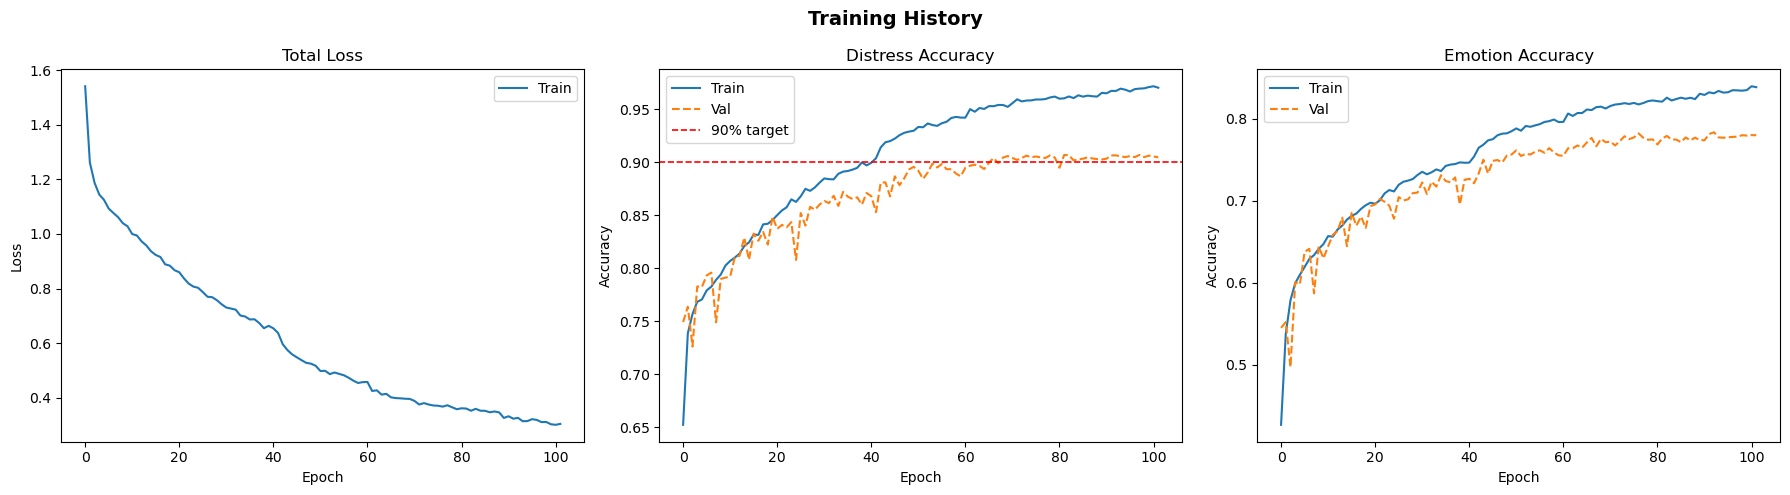

✅ Saved training_curves.png


In [40]:
# ── Section 10: Training Curves ──────────────────────────────────────────────
import matplotlib.pyplot as plt

h = history   # plain dict — no .history attribute needed

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

plot_cfg = [
    (axes[0], 'loss',         None,              'Total Loss',        'Loss'),
    (axes[1], 'distress_acc', 'val_distress_acc', 'Distress Accuracy', 'Accuracy'),
    (axes[2], 'emotion_acc',  'val_emotion_acc',  'Emotion Accuracy',  'Accuracy'),
]

for ax, train_key, val_key, title, ylabel in plot_cfg:
    ax.plot(h[train_key], label='Train')
    if val_key and val_key in h:
        ax.plot(h[val_key], label='Val', linestyle='--')
    if 'distress' in train_key:
        ax.axhline(0.90, c='red', ls='--', lw=1.2, label='90% target')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved training_curves.png")


Error sample.wav: [Errno 2] No such file or directory: 'sample.wav'
None



── Distress Report ──
              precision    recall  f1-score   support

Non-Distress       0.88      0.88      0.88      4232
    Distress       0.91      0.91      0.91      5593

    accuracy                           0.90      9825
   macro avg       0.89      0.89      0.89      9825
weighted avg       0.90      0.90      0.90      9825


── Emotion Report ──
              precision    recall  f1-score   support

       angry       0.84      0.87      0.86      1843
        fear       0.79      0.55      0.65      1896
       happy       0.87      0.77      0.81      2474
     neutral       0.70      0.83      0.76      1758
         sad       0.66      0.83      0.73      1854

    accuracy                           0.77      9825
   macro avg       0.77      0.77      0.76      9825
weighted avg       0.78      0.77      0.77      9825



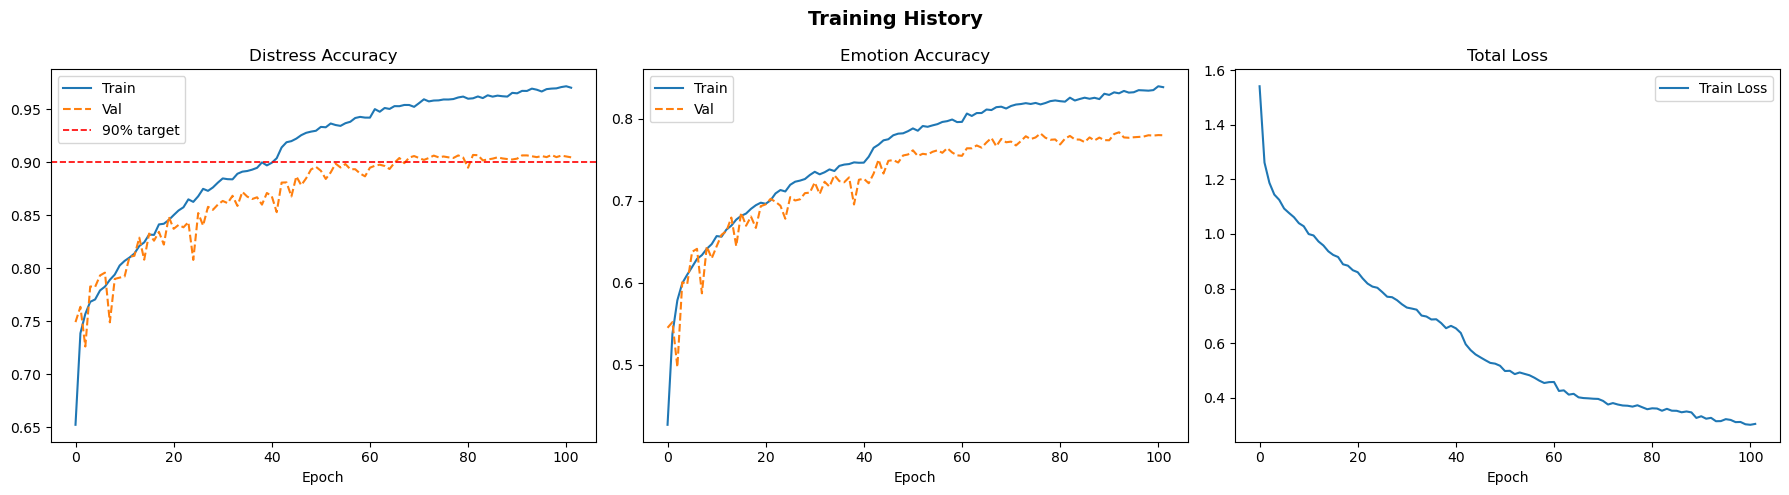

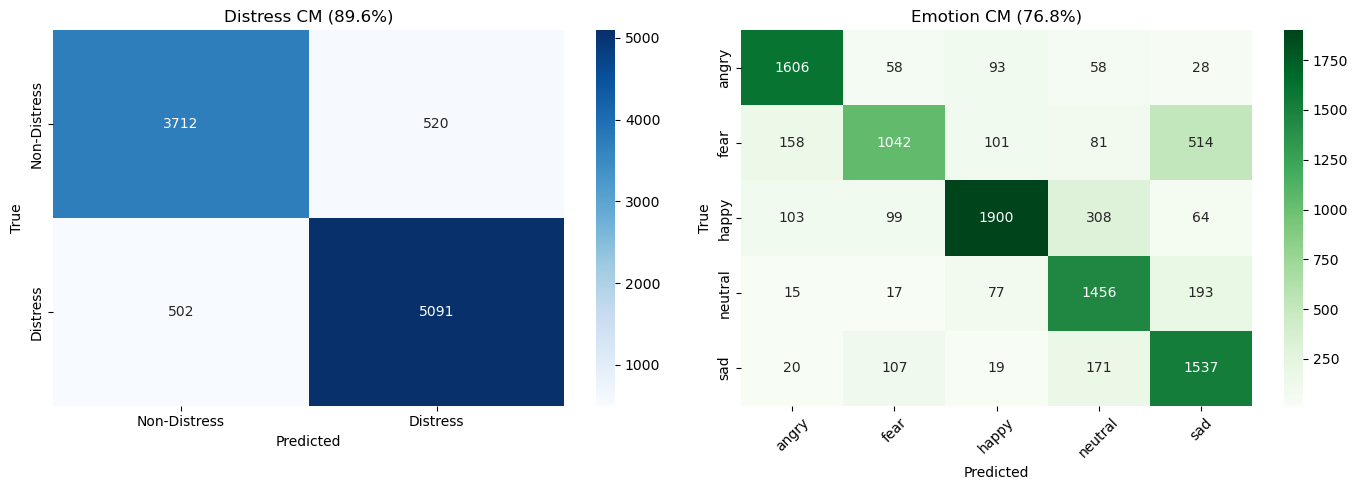

In [43]:
# ── Section 10: Reports & Plots ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ── Classification Reports ───────────────────────────────────────────────────
print("\n── Distress Report ──")
print(classification_report(yd_te, dp, target_names=['Non-Distress', 'Distress']))

print("\n── Emotion Report ──")
print(classification_report(et, ep, target_names=le.classes_))

# ── Training Curves ───────────────────────────────────────────────────────────
h = history   # plain dict from custom loop — no .history attribute

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

# Distress Accuracy
axes[0].plot(h['distress_acc'],     label='Train')
axes[0].plot(h['val_distress_acc'], label='Val', linestyle='--')
axes[0].axhline(0.90, c='red', ls='--', lw=1.2, label='90% target')
axes[0].set_title('Distress Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].legend()

# Emotion Accuracy
axes[1].plot(h['emotion_acc'],     label='Train')
axes[1].plot(h['val_emotion_acc'], label='Val', linestyle='--')
axes[1].set_title('Emotion Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].legend()

# Total Loss
axes[2].plot(h['loss'], label='Train Loss')
axes[2].set_title('Total Loss')
axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig('../models/training_curves_v2.png', dpi=120)
plt.show()

# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(yd_te, dp),
            annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Distress', 'Distress'],
            yticklabels=['Non-Distress', 'Distress'])
axes[0].set_title(f'Distress CM ({da*100:.1f}%)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(confusion_matrix(et, ep),
            annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title(f'Emotion CM ({ea*100:.1f}%)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../img/confusion_matrices_v2.png', dpi=120)
plt.show()



── Distress Report ──
              precision    recall  f1-score   support

Non-Distress       0.88      0.88      0.88      4232
    Distress       0.91      0.91      0.91      5593

    accuracy                           0.90      9825
   macro avg       0.89      0.89      0.89      9825
weighted avg       0.90      0.90      0.90      9825


── Emotion Report ──
              precision    recall  f1-score   support

       angry       0.84      0.87      0.86      1843
        fear       0.79      0.55      0.65      1896
       happy       0.87      0.77      0.81      2474
     neutral       0.70      0.83      0.76      1758
         sad       0.66      0.83      0.73      1854

    accuracy                           0.77      9825
   macro avg       0.77      0.77      0.76      9825
weighted avg       0.78      0.77      0.77      9825



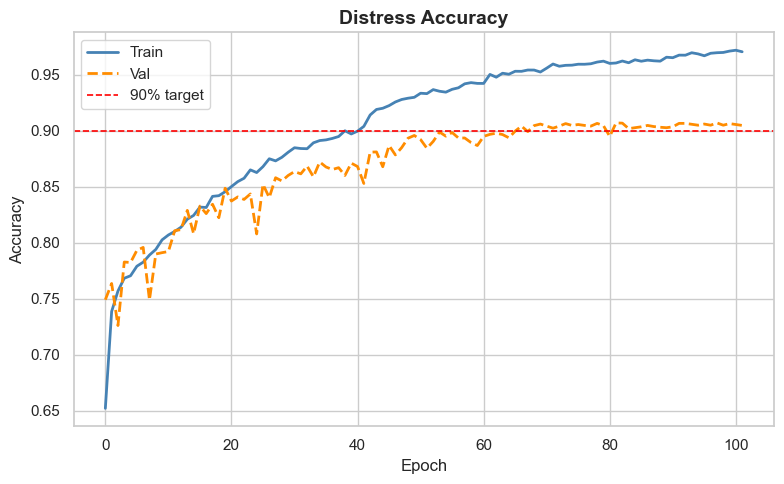

✅ Saved img1_distress_acc.png


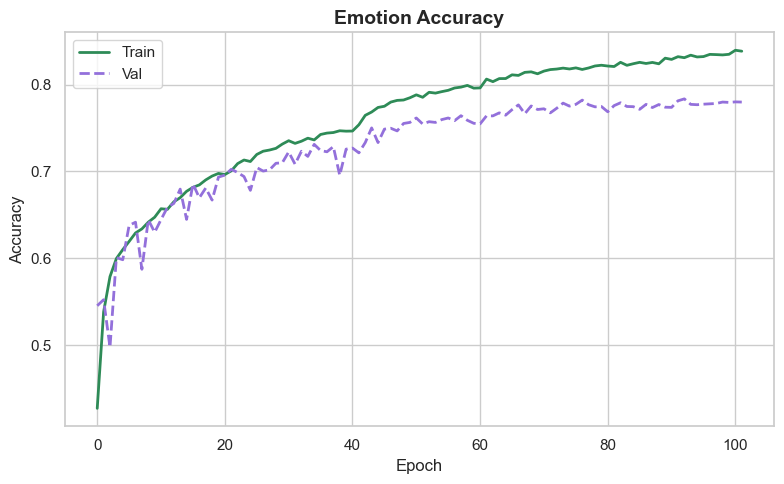

✅ Saved img2_emotion_acc.png


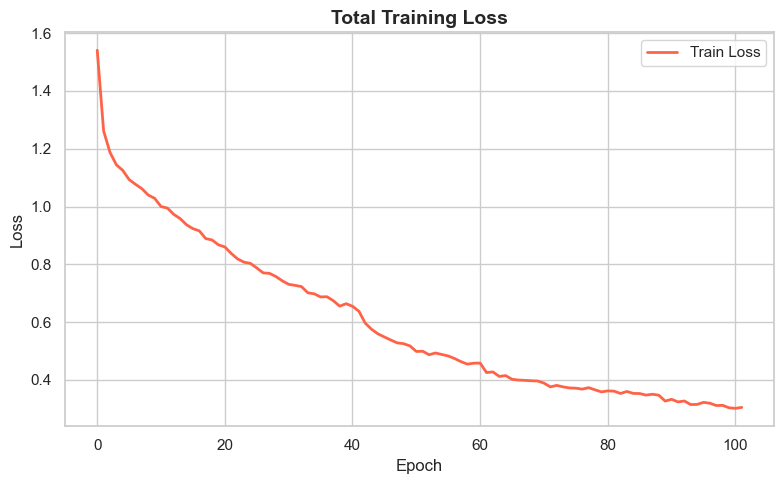

✅ Saved img3_loss.png


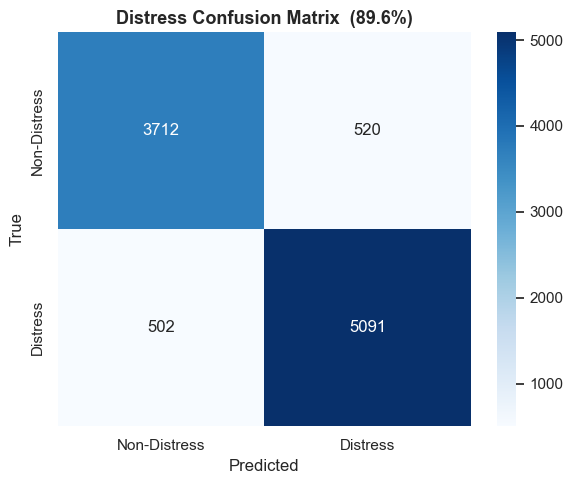

✅ Saved img4_cm_distress.png


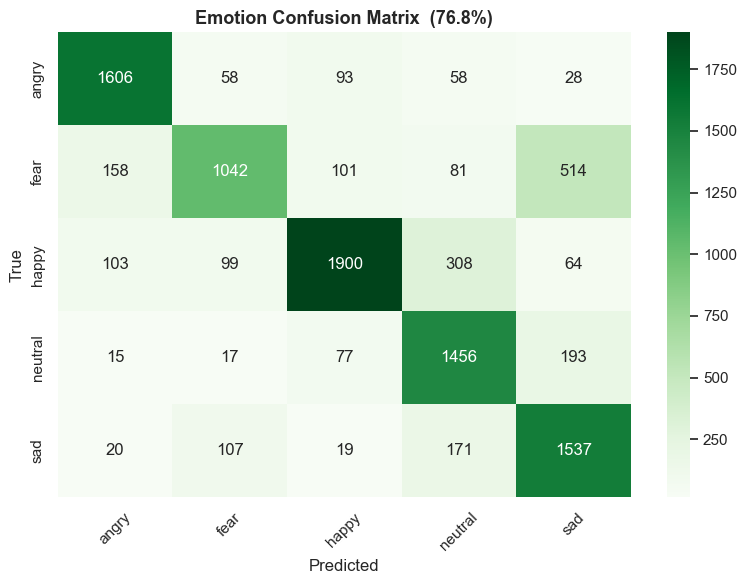

✅ Saved img5_cm_emotion.png


In [45]:
# ── Section 10: Reports & Plots — 4 Separate Images ─────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
h = history   # plain dict

# ── Classification Reports (console) ─────────────────────────────────────────
print("\n── Distress Report ──")
print(classification_report(yd_te, dp, target_names=['Non-Distress', 'Distress']))
print("\n── Emotion Report ──")
print(classification_report(et, ep, target_names=le.classes_))

# ══════════════════════════════════════════════════════════════
# IMG 1 — Distress Accuracy Curve
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(h['distress_acc'],     label='Train', color='steelblue',  linewidth=2)
ax.plot(h['val_distress_acc'], label='Val',   color='darkorange', linewidth=2, linestyle='--')
ax.axhline(0.90, color='red', linestyle='--', linewidth=1.2, label='90% target')
ax.set_title('Distress Accuracy', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); plt.tight_layout()
plt.savefig('../models/img1_distress_acc.png', dpi=150)
plt.show(); print("✅ Saved img1_distress_acc.png")

# ══════════════════════════════════════════════════════════════
# IMG 2 — Emotion Accuracy Curve
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(h['emotion_acc'],     label='Train', color='seagreen',   linewidth=2)
ax.plot(h['val_emotion_acc'], label='Val',   color='mediumpurple', linewidth=2, linestyle='--')
ax.set_title('Emotion Accuracy', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); plt.tight_layout()
plt.savefig('../models/img2_emotion_acc.png', dpi=150)
plt.show(); print("✅ Saved img2_emotion_acc.png")

# ══════════════════════════════════════════════════════════════
# IMG 3 — Total Loss Curve
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(h['loss'], label='Train Loss', color='tomato', linewidth=2)
ax.set_title('Total Training Loss', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); plt.tight_layout()
plt.savefig('../models/img3_loss.png', dpi=150)
plt.show(); print("✅ Saved img3_loss.png")
# ══════════════════════════════════════════════════════════════
# IMG 4 — Distress Confusion Matrix
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion_matrix(yd_te, dp),
            annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-Distress', 'Distress'],
            yticklabels=['Non-Distress', 'Distress'])
ax.set_title(f'Distress Confusion Matrix  ({da*100:.1f}%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('../img/img4_cm_distress.png', dpi=150)
plt.show(); print("✅ Saved img4_cm_distress.png")

# ══════════════════════════════════════════════════════════════
# IMG 5 — Emotion Confusion Matrix
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(confusion_matrix(et, ep),
            annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_title(f'Emotion Confusion Matrix  ({ea*100:.1f}%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../img/img5_cm_emotion.png', dpi=150)
plt.show(); print("✅ Saved img5_cm_emotion.png")


In [41]:
def predict_distress(audio_path,
                     model_path=MODEL_SAVE_PATH,
                     scaler_path=SCALER_SAVE_PATH,
                     le_path='../models/label_encoder_v2.joblib'):
    """Predict distress + emotion for a single audio file."""
    m, sc, le = (keras.models.load_model(model_path),
                 joblib.load(scaler_path), joblib.load(le_path))
    feat = extract_features(audio_path)
    if feat is None: return None
    x = sc.transform(feat.reshape(1,-1)).reshape(1,-1,1)
    dp, ep = m.predict(x, verbose=0)
    dp = float(dp[0][0]); ei = int(np.argmax(ep[0]))
    return {'distress_probability': round(dp,4),
            'is_distress': dp > 0.5,
            'emotion': le.classes_[ei],
            'emotion_confidence': round(float(ep[0][ei]),4)}

# Example: print(predict_distress('sample.wav'))

In [ ]:
print(predict_distress('sample.wav'))

In [5]:

FOLDER_PATH   = r"C:\Users\moham\ml\finproj\testAudio"   
AUDIO_EXTS    = ('.wav', '.mp3', '.flac', '.ogg', '.m4a')
DISTRESS_THR  = 0.5

# Load model, scaler, label encoder 
_model  = keras.models.load_model(MODEL_SAVE_PATH)
_scaler = joblib.load(SCALER_SAVE_PATH)
_le     = joblib.load('../models/label_encoder_v2.joblib')

print(f"Model loaded from: {MODEL_SAVE_PATH}")
print(f"Scanning folder  : {FOLDER_PATH}\n")

Model loaded from: ../models/distress_detection_model_v2.keras
Scanning folder  : C:\Users\moham\ml\finproj\testAudio



In [ ]:
# 01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).

Found 132 audio file(s)

File                                  Distress          Label   Top Emotion   Confidence
──────────────────────────────────────────────────────────────────────────────────────────
03-01-01-01-01-02-10.wav                0.0020 🟢 Non-Distress       neutral        69.2%
03-01-01-01-02-01-10.wav                0.0000 🟢 Non-Distress       neutral        93.5%
03-01-01-01-02-02-10.wav                0.0000 🟢 Non-Distress       neutral        87.0%
03-01-02-01-01-01-10.wav                0.0005 🟢 Non-Distress       neutral        78.1%
03-01-02-01-01-02-10.wav                0.0000 🟢 Non-Distress       neutral        73.4%
03-01-02-01-02-01-10.wav                0.0000 🟢 Non-Distress       neutral        99.4%
03-01-02-01-02-02-10.wav                0.0000 🟢 Non-Distress       neutral        99.5%
03-01-02-02-01-01-10.wav                0.0000 🟢 Non-Distress       neutral       100.0%
03-01-02-02-01-02-10.wav                0.0000 🟢 Non-Distress       neutral        

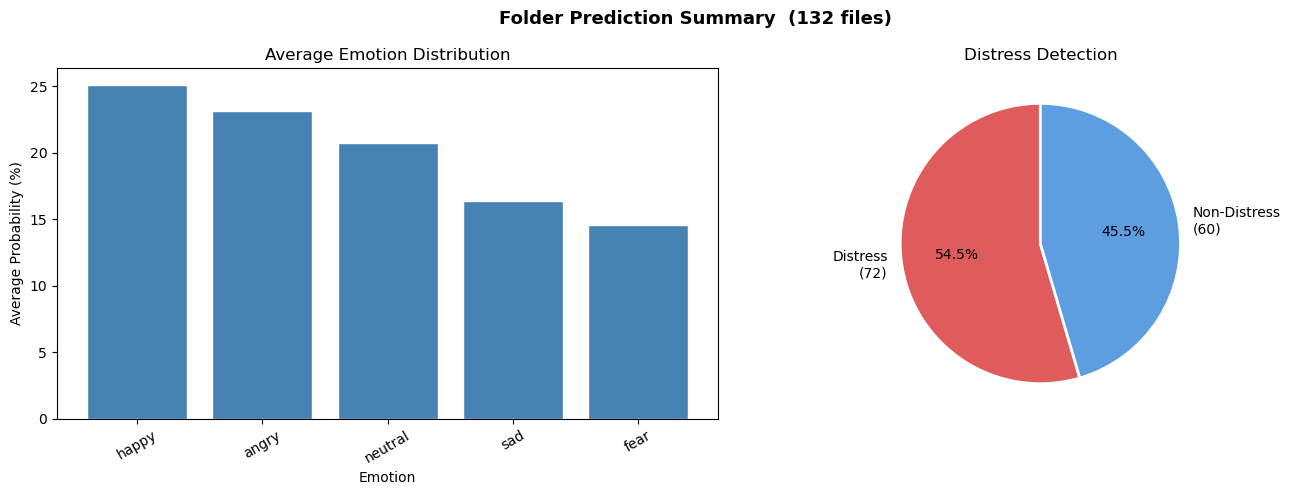


✅ Saved folder_prediction_summary.png
✅ Saved predictions CSV: ../models/folder_predictions.csv


In [6]:
# ── Collect audio files ───────────────────────────────────────────────────────
audio_files = [
    f for f in os.listdir(FOLDER_PATH)
    if f.lower().endswith(AUDIO_EXTS)
]

if not audio_files:
    print("❌ No audio files found. Check FOLDER_PATH and AUDIO_EXTS.")
else:
    print(f"Found {len(audio_files)} audio file(s)\n")
    print(f"{'File':<35} {'Distress':>10} {'Label':>14} {'Top Emotion':>13} {'Confidence':>12}")
    print("─" * 90)

    results = []

    for fname in sorted(audio_files):
        fpath = os.path.join(FOLDER_PATH, fname)

        # Feature extraction
        feat = extract_features(fpath)
        if feat is None:
            print(f"{fname:<35} {'ERROR':>10}")
            continue

        # Preprocess
        x = _scaler.transform(feat.reshape(1, -1)).reshape(1, -1, 1)

        # Predict
        d_prob_arr, e_prob_arr = _model.predict(x, verbose=0)
        d_prob    = float(d_prob_arr[0][0])
        e_probs   = e_prob_arr[0]                         # shape: (5,)
        top_ei    = int(np.argmax(e_probs))
        top_emo   = _le.classes_[top_ei]
        top_conf  = float(e_probs[top_ei])
        is_dist   = d_prob >= DISTRESS_THR

        # Per-emotion percentages for this file
        emo_pcts = {_le.classes_[i]: round(float(e_probs[i]) * 100, 1)
                    for i in range(len(_le.classes_))}

        results.append({
            'file':                fname,
            'distress_prob':       round(d_prob, 4),
            'is_distress':         is_dist,
            'top_emotion':         top_emo,
            'top_emotion_conf_%':  round(top_conf * 100, 1),
            **{f'{k}_%': v for k, v in emo_pcts.items()}
        })

        label = "🔴 DISTRESS" if is_dist else "🟢 Non-Distress"
        print(f"{fname:<35} {d_prob:>10.4f} {label:>14} {top_emo:>13} {top_conf*100:>11.1f}%")

    print("─" * 90)

    # ── Summary DataFrame ─────────────────────────────────────────────────────
    df = pd.DataFrame(results)
    print(f"\n📊 Summary  ({len(df)} files processed)")
    print(f"   Distressed files : {df['is_distress'].sum()} / {len(df)}")
    print(f"   Avg distress prob: {df['distress_prob'].mean():.4f}\n")

    # Aggregate emotion distribution across all files
    emo_cols = [c for c in df.columns if c.endswith('_%') and 'distress' not in c.lower() and 'top' not in c.lower()]
    avg_emo  = df[emo_cols].mean().sort_values(ascending=False)
    print("   Emotion Distribution (avg % across all files):")
    for emo, pct in avg_emo.items():
        bar = '█' * int(pct / 3)
        print(f"   {emo.replace('_%',''):>10}: {pct:>5.1f}%  {bar}")

    # ── Plot: Emotion Distribution ────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Folder Prediction Summary  ({len(df)} files)', fontsize=13, fontweight='bold')

    # Bar chart: avg emotion %
    emotions = [c.replace('_%', '') for c in avg_emo.index]
    axes[0].bar(emotions, avg_emo.values, color='steelblue', edgecolor='white')
    axes[0].set_title('Average Emotion Distribution')
    axes[0].set_ylabel('Average Probability (%)')
    axes[0].set_xlabel('Emotion')
    axes[0].tick_params(axis='x', rotation=30)

    # Pie chart: distress vs non-distress
    dist_count     = int(df['is_distress'].sum())
    non_dist_count = len(df) - dist_count
    axes[1].pie(
        [dist_count, non_dist_count],
        labels=[f'Distress\n({dist_count})', f'Non-Distress\n({non_dist_count})'],
        colors=['#e05c5c', '#5c9ee0'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    axes[1].set_title('Distress Detection')

    plt.tight_layout()
    plt.savefig('../img/folder_prediction_summary.png', dpi=150)
    plt.show()
    print("\n✅ Saved folder_prediction_summary.png")

    # ── Save CSV ──────────────────────────────────────────────────────────────
    csv_path = '../models/folder_predictions.csv'
    df.to_csv(csv_path, index=False)
    print(f"✅ Saved predictions CSV: {csv_path}")

In [ ]:
# 01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).

In [12]:
    for fname in sorted(audio_files):
        fpath = os.path.join(FOLDER_PATH, fname)

        # Feature extraction
        feat = extract_features(fpath)
        if feat is None:
            print(f"❌ {fname} — feature extraction failed")
            continue

        # Preprocess
        x = _scaler.transform(feat.reshape(1, -1)).reshape(1, -1, 1)

        # Predict
        d_prob_arr, e_prob_arr = _model.predict(x, verbose=0)
        d_prob  = float(d_prob_arr[0][0])
        e_probs = e_prob_arr[0]
        is_dist = d_prob >= DISTRESS_THR

        # Print result
        label = "🔴 DISTRESS" if is_dist else "🟢 Non-Distress"
        print(f"\n📄 File     : {fname}")
        print(f"   Distress : {d_prob*100:.1f}%  →  {label}")
        print(f"   Emotion Breakdown:")
        for i, emo in enumerate(_le.classes_):
            pct = float(e_probs[i]) * 100
            bar = '█' * int(pct / 4)
            marker = " ◀ top" if i == int(np.argmax(e_probs)) else ""
            print(f"      {emo:>10}: {pct:>5.1f}%  {bar}{marker}")

    print("\n" + "─" * 60)
    print("✅ Done")



📄 File     : 03-01-01-01-01-02-10.wav
   Distress : 0.2%  →  🟢 Non-Distress
   Emotion Breakdown:
           angry:   0.0%  
            fear:   0.1%  
           happy:  30.6%  ███████
         neutral:  69.2%  █████████████████ ◀ top
             sad:   0.1%  

📄 File     : 03-01-01-01-02-01-10.wav
   Distress : 0.0%  →  🟢 Non-Distress
   Emotion Breakdown:
           angry:   0.0%  
            fear:   0.0%  
           happy:   6.5%  █
         neutral:  93.5%  ███████████████████████ ◀ top
             sad:   0.0%  

📄 File     : 03-01-01-01-02-02-10.wav
   Distress : 0.0%  →  🟢 Non-Distress
   Emotion Breakdown:
           angry:   0.0%  
            fear:   0.0%  
           happy:  13.0%  ███
         neutral:  87.0%  █████████████████████ ◀ top
             sad:   0.0%  

📄 File     : 03-01-02-01-01-01-10.wav
   Distress : 0.1%  →  🟢 Non-Distress
   Emotion Breakdown:
           angry:   0.0%  
            fear:   0.0%  
           happy:  21.8%  █████
         neutral:  78.1

In [52]:
# ── Section 9: Test Set Accuracy ─────────────────────────────────────────────
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import keras

# ── Auto-detect test feature variable ────────────────────────────────────────
for _name in ['Xte', 'X_test', 'Xts', 'x_test']:
    if _name in dir():
        Xts = eval(_name)
        print(f"✅ Using test features: {_name}  shape: {Xts.shape}")
        break
else:
    raise NameError("❌ No test feature array found. Check your data split cell.")

# ── Auto-detect test label variables ─────────────────────────────────────────
# Distress labels
for _name in ['yd_te', 'yd_ts', 'y_distress_test', 'yd_test']:
    if _name in dir():
        yd_ts = eval(_name)
        print(f"✅ Using distress labels: {_name}  shape: {yd_ts.shape}")
        break
else:
    raise NameError("❌ No distress test label found.")

# Emotion labels (one-hot)
for _name in ['ye_te', 'ye_ts', 'y_emotion_test', 'ye_test']:
    if _name in dir():
        ye_ts = eval(_name)
        print(f"✅ Using emotion labels : {_name}  shape: {ye_ts.shape}")
        break
else:
    raise NameError("❌ No emotion test label found.")

# ── Load best model ───────────────────────────────────────────────────────────
best_model = keras.models.load_model(MODEL_SAVE_PATH)
print(f"\n✅ Loaded model: {MODEL_SAVE_PATH}\n")

# ── Predict ───────────────────────────────────────────────────────────────────
d_prob_arr, e_prob_arr = best_model.predict(Xts, verbose=0)

d_probs = d_prob_arr.flatten()
e_probs = e_prob_arr

dp = (d_probs >= 0.5).astype(int)
ep = np.argmax(e_probs, axis=1)

yd_te = yd_ts.flatten().astype(int)
et    = np.argmax(ye_ts, axis=1).astype(int)

# ── Accuracy ──────────────────────────────────────────────────────────────────
da = accuracy_score(yd_te, dp)
ea = accuracy_score(et, ep)

print("=" * 50)
print(f"  Distress Accuracy : {da*100:.2f}%")
print(f"  Emotion  Accuracy : {ea*100:.2f}%")
print("=" * 50)

# ── Classification Reports ────────────────────────────────────────────────────
print("\n── Distress Classification Report ──")
print(classification_report(yd_te, dp,
      target_names=['Non-Distress', 'Distress']))

print("\n── Emotion Classification Report ──")
print(classification_report(et, ep,
      target_names=le.classes_))


✅ Using test features: Xte  shape: (9825, 275, 1)
✅ Using distress labels: yd_te  shape: (9825,)
✅ Using emotion labels : ye_te  shape: (9825, 5)

✅ Loaded model: ../models/distress_detection_model_v2.keras

  Distress Accuracy : 89.60%
  Emotion  Accuracy : 76.75%

── Distress Classification Report ──
              precision    recall  f1-score   support

Non-Distress       0.88      0.88      0.88      4232
    Distress       0.91      0.91      0.91      5593

    accuracy                           0.90      9825
   macro avg       0.89      0.89      0.89      9825
weighted avg       0.90      0.90      0.90      9825


── Emotion Classification Report ──
              precision    recall  f1-score   support

       angry       0.84      0.87      0.86      1843
        fear       0.79      0.55      0.65      1896
       happy       0.87      0.77      0.81      2474
     neutral       0.70      0.83      0.76      1758
         sad       0.66      0.83      0.73      1854

    ac

In [16]:
# import os


# SAVE_PATH = r'../img/folder_prediction_summary.csv'

# def get_ground_truth(filename):
#     fn = filename
#     if fn.startswith("03-01-"):
#         parts = fn.split("-")
#         emo_code = int(parts[2])
#         emo_map = {1:"neutral", 2:"calm", 3:"happy", 4:"sad",
#                    5:"angry", 6:"fearful", 7:"disgust", 8:"surprised"}
#         distress_codes = [4, 5, 6, 7]
#         return ("RAVDESS",
#                 emo_map.get(emo_code, "unknown"),
#                 "DISTRESS" if emo_code in distress_codes else "Non-Distress")

#     elif fn.startswith("1001_"):
#         parts = fn.replace(".wav","").split("_")
#         emo = parts[2]
#         emo_map = {"ANG":"angry","DIS":"disgust","FEA":"fear",
#                    "SAD":"sad","HAP":"happy","NEU":"neutral"}
#         distress = {"ANG","DIS","FEA","SAD"}
#         return ("CREMA-D",
#                 emo_map.get(emo, "unknown"),
#                 "DISTRESS" if emo in distress else "Non-Distress")

#     elif fn.startswith("OAF_") or fn.startswith("YAF_"):
#         emo = fn.replace(".wav","").split("_")[-1]
#         distress_emos = {"angry","disgust","fear","sad","fearful"}
#         return ("TESS", emo,
#                 "DISTRESS" if emo in distress_emos else "Non-Distress")

#     else:
#         return ("Personal", "unknown", "unknown")


# rows = []
# for _, row in df.iterrows():  
#     dataset, actual_emo, actual_distress = get_ground_truth(row["file"])  
#     pred_distress = "DISTRESS" if row["is_distress"] else "Non-Distress"
#     rows.append({
#         "Dataset":              dataset,
#         "Filename":             row["file"],
#         "Actual Emotion":       actual_emo,
#         "Predicted Emotion":    row["top_emotion"],
#         "Actual Distress":      actual_distress,
#         "Predicted Distress":   pred_distress,
#         "Distress Probability": row["distress_prob"],
#         "Correct":              actual_distress == pred_distress
#     })

# analysis_df = pd.DataFrame(rows)

# os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
# analysis_df.to_csv(SAVE_PATH, index=False)
# print(f"✅ Saved {len(analysis_df)} rows → {os.path.abspath(SAVE_PATH)}")
# analysis_df.head()

In [15]:

SAVE_PATH = '../img/prediction_analysis.csv'

def get_ground_truth(filename):
    fn = filename
    if fn.startswith("03-01-"):
        parts = fn.split("-")
        emo_code = int(parts[2])
        emo_map = {1:"neutral", 2:"calm", 3:"happy", 4:"sad",
                   5:"angry", 6:"fearful", 7:"disgust", 8:"surprised"}
        return "RAVDESS", emo_map.get(emo_code, "unknown")

    elif fn.startswith("1001_"):
        parts = fn.replace(".wav","").split("_")
        emo_map = {"ANG":"angry","DIS":"disgust","FEA":"fear",
                   "SAD":"sad","HAP":"happy","NEU":"neutral"}
        return "CREMA-D", emo_map.get(parts[2], "unknown")

    elif fn.startswith("OAF_") or fn.startswith("YAF_"):
        emo = fn.replace(".wav","").split("_")[-1]
        return "TESS", emo

    else:
        return "Personal", "unknown"


rows = []
for _, row in df.iterrows():
    dataset, actual_emo = get_ground_truth(row["file"])
    rows.append({
        "Dataset":           dataset,
        "Filename":          row["file"],
        "Actual Emotion":    actual_emo,
        "Predicted Emotion": row["top_emotion"]
    })

analysis_df = pd.DataFrame(rows)

os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
analysis_df.to_csv(SAVE_PATH, index=False)
print(f"✅ Saved {len(analysis_df)} rows → {os.path.abspath(SAVE_PATH)}")
analysis_df.head(10)

✅ Saved 132 rows → C:\Users\moham\ml\finproj\5per - Copy\img\prediction_analysis.csv


,Dataset,Filename,Actual Emotion,Predicted Emotion
0,RAVDESS,03-01-01-01-01-02-10.wav,neutral,neutral
1,RAVDESS,03-01-01-01-02-01-10.wav,neutral,neutral
2,RAVDESS,03-01-01-01-02-02-10.wav,neutral,neutral
3,RAVDESS,03-01-02-01-01-01-10.wav,calm,neutral
4,RAVDESS,03-01-02-01-01-02-10.wav,calm,neutral
5,RAVDESS,03-01-02-01-02-01-10.wav,calm,neutral
6,RAVDESS,03-01-02-01-02-02-10.wav,calm,neutral
7,RAVDESS,03-01-02-02-01-01-10.wav,calm,neutral
8,RAVDESS,03-01-02-02-01-02-10.wav,calm,neutral
9,RAVDESS,03-01-02-02-02-01-10.wav,calm,neutral


In [18]:
import pandas as pd
import os

SAVE_PATH = r'../img/prediction_analysiss.csv'

def get_actual_distress(filename):
    fn = filename
    if fn.startswith("03-01-"):
        emo_code = int(fn.split("-")[2])
        return "RAVDESS", "DISTRESS" if emo_code in [4,5,6,7] else "Non-Distress"

    elif fn.startswith("1001_"):
        emo = fn.replace(".wav","").split("_")[2]
        return "CREMA-D", "DISTRESS" if emo in {"ANG","DIS","FEA","SAD"} else "Non-Distress"

    elif fn.startswith("OAF_") or fn.startswith("YAF_"):
        emo = fn.replace(".wav","").split("_")[-1]
        return "TESS", "DISTRESS" if emo in {"angry","disgust","fear","sad","fearful"} else "Non-Distress"

    else:
        return "Personal", "unknown"


rows = []
for _, row in df.iterrows():
    dataset, actual_distress = get_actual_distress(row["file"])
    pred_distress = "DISTRESS" if row["is_distress"] else "Non-Distress"
    rows.append({
        "Dataset":            dataset,
        "Filename":           row["file"],
        "Actual Distress":    actual_distress,
        "Predicted Distress": pred_distress
    })

analysis_df = pd.DataFrame(rows)

os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
analysis_df.to_csv(SAVE_PATH, index=False)
print(f"✅ Saved {len(analysis_df)} rows → {os.path.abspath(SAVE_PATH)}")
analysis_df.head(10)

✅ Saved 132 rows → C:\Users\moham\ml\finproj\5per - Copy\img\prediction_analysiss.csv


,Dataset,Filename,Actual Distress,Predicted Distress
0,RAVDESS,03-01-01-01-01-02-10.wav,Non-Distress,Non-Distress
1,RAVDESS,03-01-01-01-02-01-10.wav,Non-Distress,Non-Distress
2,RAVDESS,03-01-01-01-02-02-10.wav,Non-Distress,Non-Distress
3,RAVDESS,03-01-02-01-01-01-10.wav,Non-Distress,Non-Distress
4,RAVDESS,03-01-02-01-01-02-10.wav,Non-Distress,Non-Distress
5,RAVDESS,03-01-02-01-02-01-10.wav,Non-Distress,Non-Distress
6,RAVDESS,03-01-02-01-02-02-10.wav,Non-Distress,Non-Distress
7,RAVDESS,03-01-02-02-01-01-10.wav,Non-Distress,Non-Distress
8,RAVDESS,03-01-02-02-01-02-10.wav,Non-Distress,Non-Distress
9,RAVDESS,03-01-02-02-02-01-10.wav,Non-Distress,Non-Distress


In [2]:
# import os
# import pandas as pd
# import numpy as np

# SAVE_PATH = r'../img/full_dataset_analysis.csv'

# DATASET_DIRS = {
#     "RAVDESS": RAVDESS_PATH,
#     "TESS":    TESS_PATH,
#     "CREMA-D": CREMA_PATH,
# }

# AUDIO_EXTS = {'.wav', '.mp3', '.flac', '.ogg', '.m4a'}

# def get_actual_distress(filename):
#     fn = filename
#     if fn.startswith("03-01-"):
#         emo_code = int(fn.split("-")[2])
#         return "RAVDESS", "DISTRESS" if emo_code in [4,5,6,7] else "Non-Distress"
#     elif fn.startswith("1001_"):
#         emo = fn.replace(".wav","").split("_")[2]
#         return "CREMA-D", "DISTRESS" if emo in {"ANG","DIS","FEA","SAD"} else "Non-Distress"
#     elif fn.startswith("OAF_") or fn.startswith("YAF_"):
#         emo = fn.replace(".wav","").split("_")[-1]
#         return "TESS", "DISTRESS" if emo in {"angry","disgust","fear","sad","fearful"} else "Non-Distress"
#     else:
#         return "Personal", "unknown"

# all_files = []
# for folder in DATASET_DIRS.values():
#     for root, _, files in os.walk(folder):
#         for f in files:
#             if os.path.splitext(f)[1].lower() in AUDIO_EXTS:
#                 all_files.append(os.path.join(root, f))

# print(f"Found {len(all_files)} audio files. Starting predictions...")

# rows = []
# for i, fpath in enumerate(all_files):
#     fname = os.path.basename(fpath)
#     try:
#         feats        = extract_features(fpath)
#         feats_scaled = _scaler.transform([feats])          # ✅ _scaler
#         preds        = _model.predict(feats_scaled, verbose=0)  # ✅ _model
#         d_prob       = float(preds[0][0])
#         pred_distress = "DISTRESS" if d_prob >= DISTRESS_THR else "Non-Distress"
#         dataset, actual_distress = get_actual_distress(fname)
#         rows.append({
#             "Dataset":            dataset,
#             "Filename":           fname,
#             "Actual Distress":    actual_distress,
#             "Predicted Distress": pred_distress,
#         })
#         if (i+1) % 500 == 0:
#             print(f"  [{i+1}/{len(all_files)}] done...")
#     except Exception as e:
#         print(f"  ⚠️ Skipped {fname}: {e}")

# analysis_df = pd.DataFrame(rows)
# os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)A
# analysis_df.to_csv(SAVE_PATH, index=False)

# known   = analysis_df[analysis_df["Actual Distress"] != "unknown"]
# correct = (known["Actual Distress"] == known["Predicted Distress"]).sum()
# print(f"\n✅ Saved {len(analysis_df)} rows → {os.path.abspath(SAVE_PATH)}")
# print(f"📊 Accuracy: {correct}/{len(known)} = {correct/len(known)*100:.1f}%")
# display(analysis_df.head(10))